# 05b — Detectability power curve before risk-model redesign

The previous diagnostic showed that the current 8-feature auxiliary detector is essentially at chance level on held-out validation data.

This notebook asks a more fundamental question:

> **Is there measurable steganalysis signal at the frozen net-payload levels at all?**

The answer determines the next scientific step.

We use a neutral **random block allocator** so that the test does not depend on the current detectability-risk model.

Two stronger detector families are considered:

1. **SRM-lite** residual/co-occurrence features + logistic regression;
2. **Residual CNN** as an optional confirmation detector.

No test-split images are used.


In [1]:
from pathlib import Path
import json, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdhlab.io import read_gray
from rdhlab.blocks import iter_blocks
from rdhlab.features import predictability_score
from rdhlab.pipeline import (
    load_payload_freeze,
    run_frozen_image,
)
from rdhlab.detectors import (
    fit_rich_detector,
    detector_metrics,
    paired_detector_bootstrap,
    train_residual_cnn,
    score_residual_cnn,
)

config = yaml.safe_load(Path('/workspace/config/experiment.yaml').read_text())
seed = int(config['project']['seed'])
bs = int(config['dataset']['block_size'])
fixed_fpr = float(config['detectors']['fixed_fpr'])

manifest = pd.read_csv(config['dataset']['prepared_manifest'])
train = manifest[manifest.split == 'train'].reset_index(drop=True)
val = manifest[manifest.split == 'validation'].reset_index(drop=True)

freeze = load_payload_freeze('/workspace/config/frozen_payloads.json')
frozen_levels = sorted(map(float, freeze['levels']))

cap_path = Path('/workspace/results/payload_freeze/validation_capacity.csv')
cap = pd.read_csv(cap_path) if cap_path.exists() else None

outdir = Path('/workspace/results/detectability_power')
outdir.mkdir(parents=True, exist_ok=True)

print('Frozen net-payload levels:', frozen_levels)
print('Train images:', len(train), 'Validation images:', len(val))


Frozen net-payload levels: [0.003, 0.006, 0.009, 0.012]
Train images: 6000 Validation images: 2000


## Neutral allocator

The random strategy does not require a detectability model.  
To avoid contaminating the power analysis with the weak old \(D_i\), the object below supplies only the fields required by the allocator and sets detectability risk to zero.


In [2]:
class NeutralRiskModel:
    def __init__(self, block_size):
        self.block_size = int(block_size)

    def score_image_blocks(self, image, image_key=''):
        rows = []
        for bid, y, x, block in iter_blocks(image, self.block_size):
            rows.append({
                'block_id': int(bid),
                'y': int(y),
                'x': int(x),
                'predictability': float(predictability_score(block)),
                'detectability_risk': 0.0,
            })
        return rows

neutral = NeutralRiskModel(bs)


## Diagnostic payload grid

The frozen levels remain unchanged.

For **diagnostic validation only**, the notebook may additionally inspect higher payloads derived from the validation-capacity distribution. These diagnostic levels are never written to `frozen_payloads.json` and must not be reported as predeclared final-test levels.


In [3]:
diagnostic_levels = list(frozen_levels)

if cap is not None and 'max_net_bpp' in cap.columns:
    q25 = float(cap.max_net_bpp.quantile(0.25))
    q50 = float(cap.max_net_bpp.quantile(0.50))
    extra = [0.90*q25, 0.90*q50]
    for x in extra:
        if x > 0 and all(abs(x-y) > 1e-6 for y in diagnostic_levels):
            diagnostic_levels.append(float(x))

diagnostic_levels = sorted(diagnostic_levels)

print('Diagnostic grid:')
for x in diagnostic_levels:
    tag = 'FROZEN' if any(abs(x-y)<1e-9 for y in frozen_levels) else 'VALIDATION-DIAGNOSTIC'
    print(f'  {x:.6f} bpp  [{tag}]')


Diagnostic grid:
  0.003000 bpp  [FROZEN]
  0.006000 bpp  [FROZEN]
  0.009000 bpp  [FROZEN]
  0.012000 bpp  [FROZEN]
  0.027188 bpp  [VALIDATION-DIAGNOSTIC]
  0.047832 bpp  [VALIDATION-DIAGNOSTIC]


## Generate a neutral random-allocation dataset

To keep runtime manageable, defaults are:

- up to 1500 train images per payload;
- 1000 validation images for the SRM-lite power curve.

Infeasible cases are skipped and feasibility is reported explicitly.


In [4]:
N_TRAIN = min(1500, len(train))
N_VAL = min(1000, len(val))

def make_pairs(frame, n_images, payload_bpp, label):
    covers, stegos, ids = [], [], []
    attempted = min(n_images, len(frame))
    for j, row in frame.head(attempted).iterrows():
        x = read_gray(row.path)
        rr = run_frozen_image(
            x,
            str(row.source_id),
            float(payload_bpp),
            'random',
            neutral,
            alpha=0.5,
            block_size=bs,
            seed=seed,
        )
        if rr['feasible']:
            covers.append(x)
            stegos.append(rr['stego'])
            ids.append(str(row.source_id))
        if (j + 1) % 250 == 0:
            print(label, f'{j+1}/{attempted}', 'feasible:', len(covers))
    return covers, stegos, ids, attempted


## 1. SRM-lite detectability power curve

A separate SRM-lite detector is fitted for each payload using only train images and evaluated on unseen validation images.

The central quantities are:

\[
\mathrm{ROC\mbox{-}AUC}
\]

and

\[
\mathrm{TPR}@\mathrm{FPR}=5\%.
\]


In [5]:
rows = []
cache = {}

for level in diagnostic_levels:
    print('\n=== payload', level, '===')
    tr_c, tr_s, tr_ids, tr_attempted = make_pairs(train, N_TRAIN, level, 'train')
    va_c, va_s, va_ids, va_attempted = make_pairs(val, N_VAL, level, 'validation')

    cache[level] = {
        'train_cover': tr_c, 'train_stego': tr_s,
        'val_cover': va_c, 'val_stego': va_s,
        'val_ids': va_ids,
    }

    if len(tr_c) < 100 or len(va_c) < 100:
        rows.append({
            'payload_bpp': level,
            'is_frozen': level in frozen_levels,
            'train_feasible_fraction': len(tr_c)/max(tr_attempted,1),
            'val_feasible_fraction': len(va_c)/max(va_attempted,1),
            'n_train_pairs': len(tr_c),
            'n_val_pairs': len(va_c),
            'auc': np.nan,
            'tpr_at_5pct_fpr': np.nan,
        })
        continue

    det = fit_rich_detector(tr_c, tr_s, seed=seed)

    cscore = np.asarray([det.score(x) for x in va_c], dtype=float)
    sscore = np.asarray([det.score(x) for x in va_s], dtype=float)

    scores = np.column_stack([cscore, sscore]).reshape(-1)
    y = np.tile([0,1], len(cscore))

    m = detector_metrics(y, scores, fixed_fpr=fixed_fpr)
    ci = paired_detector_bootstrap(
        cscore, sscore,
        fixed_fpr=fixed_fpr,
        n_resamples=int(config['statistics']['cluster_bootstrap_resamples']),
        confidence=float(config['statistics']['confidence']),
        seed=seed + int(round(level*1e6)),
    )

    rows.append({
        'payload_bpp': level,
        'is_frozen': any(abs(level-x)<1e-9 for x in frozen_levels),
        'train_feasible_fraction': len(tr_c)/max(tr_attempted,1),
        'val_feasible_fraction': len(va_c)/max(va_attempted,1),
        'n_train_pairs': len(tr_c),
        'n_val_pairs': len(va_c),
        'auc': m['auc'],
        'auc_ci_low': ci['auc_low'],
        'auc_ci_high': ci['auc_high'],
        'tpr_at_5pct_fpr': m['tpr_at_fpr'],
        'tpr_ci_low': ci['tpr_low'],
        'tpr_ci_high': ci['tpr_high'],
        'cover_score_mean': float(cscore.mean()),
        'stego_score_mean': float(sscore.mean()),
        'paired_score_delta_mean': float((sscore-cscore).mean()),
        'paired_score_delta_median': float(np.median(sscore-cscore)),
    })

power = pd.DataFrame(rows).sort_values('payload_bpp').reset_index(drop=True)
power.to_csv(outdir/'srm_lite_power_curve.csv', index=False)
display(power)



=== payload 0.003 ===
train 250/1500 feasible: 250
train 500/1500 feasible: 500
train 750/1500 feasible: 750
train 1000/1500 feasible: 1000
train 1250/1500 feasible: 1250
train 1500/1500 feasible: 1500
validation 250/1000 feasible: 250
validation 500/1000 feasible: 500
validation 750/1000 feasible: 749
validation 1000/1000 feasible: 998

=== payload 0.006 ===
train 250/1500 feasible: 250
train 500/1500 feasible: 500
train 750/1500 feasible: 750
train 1000/1500 feasible: 999
train 1250/1500 feasible: 1248
train 1500/1500 feasible: 1498
validation 250/1000 feasible: 249
validation 500/1000 feasible: 499
validation 750/1000 feasible: 746
validation 1000/1000 feasible: 989

=== payload 0.009 ===
train 250/1500 feasible: 250
train 500/1500 feasible: 497
train 750/1500 feasible: 744
train 1000/1500 feasible: 992
train 1250/1500 feasible: 1233
train 1500/1500 feasible: 1480
validation 250/1000 feasible: 248
validation 500/1000 feasible: 493
validation 750/1000 feasible: 733
validation 1000/1

,payload_bpp,is_frozen,train_feasible_fraction,val_feasible_fraction,n_train_pairs,n_val_pairs,auc,auc_ci_low,auc_ci_high,tpr_at_5pct_fpr,tpr_ci_low,tpr_ci_high,cover_score_mean,stego_score_mean,paired_score_delta_mean,paired_score_delta_median
0,0.003000,True,1.000000,0.998,1500,998,0.746209,0.732394,0.760969,0.324649,0.288577,0.363753,0.387034,0.624677,0.237643,0.151201
1,0.006000,True,0.998667,0.989,1498,989,0.796436,0.782934,0.810140,0.379171,0.350859,0.415571,0.347538,0.662287,0.314749,0.245874
2,0.009000,True,0.986667,0.967,1480,967,0.847086,0.833966,0.860648,0.457084,0.415719,0.504654,0.301999,0.705297,0.403298,0.354527
3,0.012000,True,0.968000,0.933,1452,933,0.885626,0.873275,0.898184,0.556270,0.511254,0.603430,0.261752,0.748748,0.486996,0.493609
4,0.027188,False,0.790667,0.717,1186,717,0.986901,0.982493,0.990838,0.913529,0.887029,0.951185,0.115948,0.914020,0.798072,0.912829
5,0.047832,False,0.487333,0.452,731,452,0.999569,0.999031,0.999912,0.997788,0.993363,1.000000,0.031995,0.973527,0.941532,0.987525


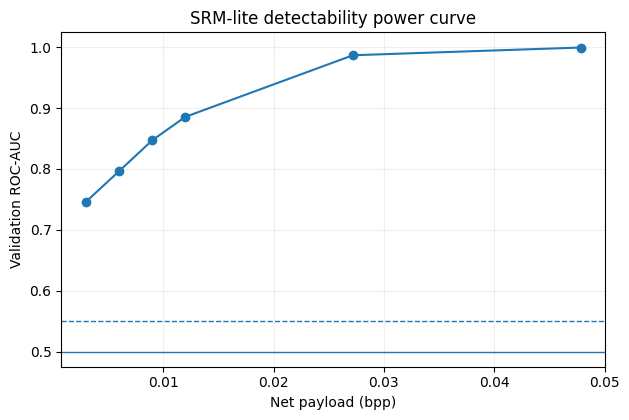

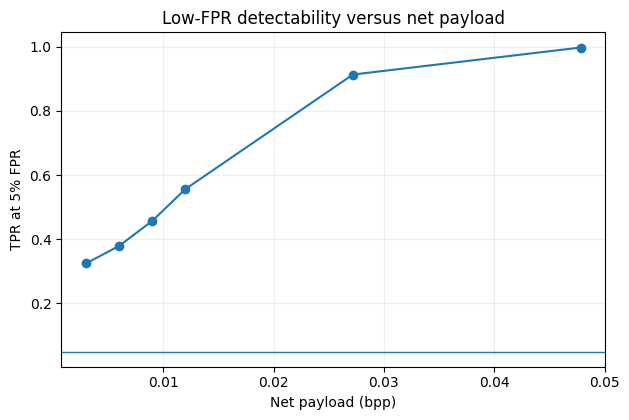

In [6]:
fig, ax = plt.subplots(figsize=(6.4,4.3))
ax.plot(power.payload_bpp, power.auc, marker='o')
ax.axhline(0.5, linewidth=1)
ax.axhline(0.55, linewidth=1, linestyle='--')
ax.set_xlabel('Net payload (bpp)')
ax.set_ylabel('Validation ROC-AUC')
ax.set_title('SRM-lite detectability power curve')
ax.grid(True, alpha=.2)
fig.tight_layout()
fig.savefig(outdir/'srm_lite_power_curve.png', dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(6.4,4.3))
ax.plot(power.payload_bpp, power.tpr_at_5pct_fpr, marker='o')
ax.axhline(0.05, linewidth=1)
ax.set_xlabel('Net payload (bpp)')
ax.set_ylabel('TPR at 5% FPR')
ax.set_title('Low-FPR detectability versus net payload')
ax.grid(True, alpha=.2)
fig.tight_layout()
fig.savefig(outdir/'srm_lite_tpr_curve.png', dpi=300)
plt.show()


## 2. Residual-CNN confirmation at the most informative payload

The SRM-lite curve is used only to choose a **diagnostic validation payload** for confirmation.

This is not final test-set model selection.

By default, the payload with the highest SRM-lite validation AUC is checked with a residual CNN. The CNN is trained on train images and evaluated on a disjoint validation subset.


In [ ]:
RUN_CNN_CONFIRMATION = True

cnn_summary = None

if RUN_CNN_CONFIRMATION:
    valid_power = power[np.isfinite(power.auc)].copy()
    if len(valid_power):
        chosen_level = float(valid_power.sort_values('auc', ascending=False).iloc[0].payload_bpp)
        print('CNN diagnostic payload:', chosen_level)

        # Build a fresh pair set so that the CNN confirmation is not restricted
        # to the exact SRM-lite validation sample.
        N_CNN_TRAIN = min(int(config['detectors']['cnn_train_images']), len(train))
        N_CNN_VAL = min(int(config['detectors']['cnn_validation_images']), len(val))

        tr_c, tr_s, _, tr_attempted = make_pairs(train, N_CNN_TRAIN, chosen_level, 'cnn train')

        # Use the second half of validation where possible.
        val_offset = min(1000, max(0, len(val)-N_CNN_VAL))
        val_confirm = val.iloc[val_offset:val_offset+N_CNN_VAL].reset_index(drop=True)
        va_c, va_s, _, va_attempted = make_pairs(val_confirm, N_CNN_VAL, chosen_level, 'cnn validation')

        if len(tr_c) >= 100 and len(va_c) >= 100:
            model, history, device = train_residual_cnn(
                tr_c, tr_s,
                validation=(va_c, va_s),
                epochs=int(config['detectors']['cnn_epochs']),
                batch_size=int(config['detectors']['cnn_batch_size']),
                seed=seed,
            )
            cscore = score_residual_cnn(
                model, va_c, device=device,
                batch_size=int(config['detectors']['cnn_batch_size'])
            )
            sscore = score_residual_cnn(
                model, va_s, device=device,
                batch_size=int(config['detectors']['cnn_batch_size'])
            )
            yy = np.tile([0,1], len(cscore))
            ss = np.column_stack([cscore,sscore]).reshape(-1)
            m = detector_metrics(yy, ss, fixed_fpr=fixed_fpr)
            ci = paired_detector_bootstrap(
                cscore, sscore,
                fixed_fpr=fixed_fpr,
                n_resamples=int(config['statistics']['cluster_bootstrap_resamples']),
                confidence=float(config['statistics']['confidence']),
                seed=seed+777,
            )
            cnn_summary = {
                'payload_bpp': chosen_level,
                'device': device,
                'n_train_pairs': len(tr_c),
                'n_validation_pairs': len(va_c),
                **m,
                **ci,
                'cover_score_mean': float(cscore.mean()),
                'stego_score_mean': float(sscore.mean()),
            }
            print('CNN history:')
            display(pd.DataFrame(history))
            display(pd.DataFrame([cnn_summary]))
        else:
            print('Not enough feasible pairs for CNN confirmation.')
    else:
        print('No finite SRM-lite result available.')

if cnn_summary is not None:
    (outdir/'cnn_confirmation.json').write_text(
        json.dumps(cnn_summary, indent=2), encoding='utf-8'
    )


CNN diagnostic payload: 0.047831726074218754
cnn train 250/2000 feasible: 106
cnn train 500/2000 feasible: 223
cnn train 750/2000 feasible: 321
cnn train 1000/2000 feasible: 445
cnn train 1250/2000 feasible: 579
cnn train 1500/2000 feasible: 731
cnn train 1750/2000 feasible: 860
cnn train 2000/2000 feasible: 953
cnn validation 250/500 feasible: 165
cnn validation 500/500 feasible: 349


## 3. Decision rule for the next experiment

This notebook does **not** define a new \(D_i\). It determines whether doing so is statistically meaningful.

Recommended interpretation:

- **All frozen levels AUC < 0.55 and diagnostic high levels also near 0.5:**  
  current embedding regime is below detector sensitivity; detectability-aware allocation is not identifiable with the tested detectors.

- **Frozen levels near chance, higher diagnostic payload detectable:**  
  train/probe a local risk model at a stronger diagnostic payload, then test transfer to frozen payloads.

- **At least one frozen level clearly detectable:**  
  redesign \(D_i\) using a stronger local residual representation, then validate it against an independent image-level detector.

The 0.55 value below is a diagnostic threshold, not a universal steganalysis standard.


In [ ]:
frozen_power = power[power.is_frozen == True]
max_frozen_auc = float(frozen_power.auc.max()) if frozen_power.auc.notna().any() else np.nan
max_all_auc = float(power.auc.max()) if power.auc.notna().any() else np.nan
cnn_auc = None if cnn_summary is None else float(cnn_summary['auc'])

print('Max SRM-lite AUC on frozen levels:', max_frozen_auc)
print('Max SRM-lite AUC on diagnostic grid:', max_all_auc)
print('CNN confirmation AUC:', cnn_auc)
print()

if np.isfinite(max_all_auc) and max_all_auc < 0.55 and (cnn_auc is None or cnn_auc < 0.55):
    decision = 'DETECTABILITY_SIGNAL_WEAK_ACROSS_TESTED_PAYLOADS'
    print('DECISION:', decision)
    print('Do not build the next allocator around a learned D_i yet.')
    print('First reconsider payload regime / detector sensitivity / risk definition.')
elif (not np.isfinite(max_frozen_auc) or max_frozen_auc < 0.55) and max_all_auc >= 0.55:
    decision = 'SIGNAL_EMERGES_ONLY_AT_HIGHER_DIAGNOSTIC_PAYLOAD'
    print('DECISION:', decision)
    print('Use the detectable diagnostic payload to develop a local risk proxy, then test transfer downward.')
else:
    decision = 'DETECTABILITY_SIGNAL_PRESENT_AT_FROZEN_PAYLOAD'
    print('DECISION:', decision)
    print('Proceed to a stronger local residual-risk proxy and validation-only allocator tuning.')

summary = {
    'max_srm_lite_auc_frozen': max_frozen_auc,
    'max_srm_lite_auc_all_diagnostic': max_all_auc,
    'cnn_confirmation_auc': cnn_auc,
    'decision': decision,
    'note': 'Validation-only diagnostic; frozen payload configuration was not modified.'
}
(outdir/'power_curve_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
summary


## Outputs

- `results/detectability_power/srm_lite_power_curve.csv`
- `results/detectability_power/srm_lite_power_curve.png`
- `results/detectability_power/srm_lite_tpr_curve.png`
- `results/detectability_power/cnn_confirmation.json` (when enabled)
- `results/detectability_power/power_curve_summary.json`

Run this notebook **before** redesigning the detectability-risk term and before the full frozen test.
